# EDA
- Andreas
blandade tester på vår data


# SETUPS
- Imports
- Setups

In [1]:
import pandas as pd
import duckdb
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
})

STAD_FARGER = {
    'Stockholm': '#2E86AB',
    'Malmö':     '#3BB273', 
    'Göteborg':  '#E84855',
}

print('BOOOOM')

BOOOOM


# LADDA IN DATAN (DUCKDB)

In [3]:
df_bostader  = pd.read_csv('../ETL_Pipline/bostader.csv')
df_priser    = pd.read_csv('../ETL_Pipline/priser.csv')
df_platser   = pd.read_csv('../ETL_Pipline/platser.csv')
df_visningar = pd.read_csv('../ETL_Pipline/visningar.csv')

con = duckdb.connect()
con.register('bostader',  df_bostader)
con.register('priser',    df_priser)
con.register('platser',   df_platser)
con.register('visningar', df_visningar)

print('TABELLER:')
print(f'  platser:   {len(df_platser)} RADER')
print(f'  bostader:  {len(df_bostader)} RADER')
print(f'  priser:    {len(df_priser)} RADER')
print(f'  visningar: {len(df_visningar)} RADER')

TABELLER:
  platser:   20 RADER
  bostader:  1000 RADER
  priser:    1000 RADER
  visningar: 2 RADER


# JOIN TABLES DUCKDB

In [4]:
query = """
    SELECT *
    FROM bostader b
    JOIN priser    p  ON b.id       = p.bostad_id
    JOIN platser   pl ON b.plats_id = pl.plats_id
"""

df = con.execute(query).df()
df['created_at'] = pd.to_datetime(df['created_at'])

print(f'Sammansatt tabell: {df.shape[0]} rader, {df.shape[1]} kolumner')
df.head()

Sammansatt tabell: 1000 rader, 30 kolumner


,id,typ,upplåtelseform,rum,boyta,boyta_enhet,tillgänglig,created_at,adress,lat,...,bostad_id,pris,avgift,kvadratmeterpris,pris_per_kvm,valuta,område,stad,plats_id_1,kommun_befolkning
0,1,hus,köpa,4,108,m²,True,2025-08-29,Drottninggatan 28,59.33820,...,1,11411993,4177,105666,105667.0,SEK,Bromma,Stockholm,1,995574
1,2,hus,köpa,6,138,m²,True,2026-03-18,Skolvägen 104,55.58171,...,2,6959222,2820,50429,50429.0,SEK,Rosengård,Malmö,2,365644
2,3,lägenhet,hyra,3,75,m²,True,2025-09-22,Drottninggatan 90,55.60470,...,3,10345,0,0,138.0,SEK,Västra Hamnen,Malmö,3,365644
3,4,lägenhet,köpa,3,69,m²,True,2026-01-01,Kyrkogatan 33,57.69446,...,4,3484199,3983,50495,50496.0,SEK,Linnéstaden,Göteborg,4,608993
4,5,lägenhet,hyra,2,42,m²,False,2025-09-14,Hornsgatan 94,55.58295,...,5,7077,0,0,168.0,SEK,Limhamn,Malmö,5,365644


# TESTER

In [5]:
# Kvalitetstest av datan
print('=== Datatyper & null-värden ===')
print(df.info())

=== Datatyper & null-värden ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     1000 non-null   int64         
 1   typ                    1000 non-null   object        
 2   upplåtelseform         1000 non-null   object        
 3   rum                    1000 non-null   int64         
 4   boyta                  1000 non-null   int64         
 5   boyta_enhet            1000 non-null   object        
 6   tillgänglig            1000 non-null   bool          
 7   created_at             1000 non-null   datetime64[ns]
 8   adress                 1000 non-null   object        
 9   lat                    1000 non-null   float64       
 10  lon                    1000 non-null   float64       
 11  plats_id               1000 non-null   int64         
 12  sparad                 1000 non

In [6]:
print("\n--- YTA / BOYTA ---")
print(f"Störst: {df['boyta'].max()} kvm")
print(f"Minst: {df['boyta'].min()} kvm")
print(f"Medel: {df['boyta'].mean():.0f} kvm")


--- YTA / BOYTA ---
Störst: 168 kvm
Minst: 18 kvm
Medel: 81 kvm


In [7]:
display(df[['pris', 'avgift', 'rum', 'boyta', 'pris_per_kvm']].describe().round(0))

,pris,avgift,rum,boyta,pris_per_kvm
count,1000.0,1000.0,1000.0,1000.0,1000.0
mean,4372299.0,2984.0,3.0,81.0,53728.0
std,4077370.0,2402.0,2.0,41.0,38147.0
min,2166.0,0.0,1.0,18.0,120.0
25%,1013853.0,1529.0,2.0,46.0,33472.0
50%,3604906.0,2840.0,4.0,80.0,50628.0
75%,6621601.0,4126.0,5.0,112.0,76932.0
max,21282713.0,12538.0,6.0,168.0,132518.0


In [8]:
print(df_priser.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   bostad_id         1000 non-null   int64  
 1   pris              1000 non-null   int64  
 2   avgift            1000 non-null   int64  
 3   kvadratmeterpris  1000 non-null   int64  
 4   pris_per_kvm      1000 non-null   float64
 5   valuta            1000 non-null   object 
dtypes: float64(1), int64(4), object(1)
memory usage: 47.0+ KB
None


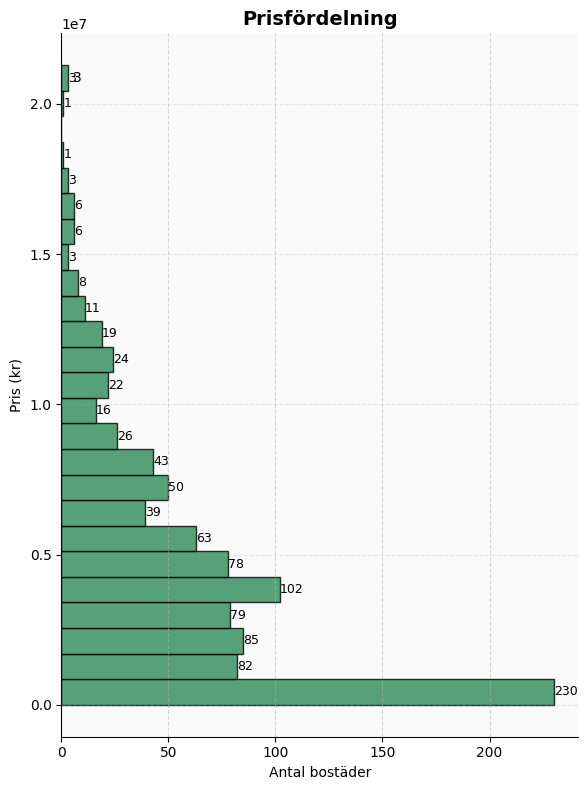

In [9]:
plt.figure(figsize=(6,8))

counts, bins, patches = plt.hist(
    df['pris'],
    bins=25,
    orientation='horizontal',
    color='seagreen',
    edgecolor='black',
    alpha=0.8
)

for count, patch in zip(counts, patches):
    y = patch.get_y() + patch.get_height() / 2
    x = count
    
    if count > 0:  
        plt.text(x, y, f'{int(count)}',
                 va='center', ha='left', fontsize=9)

plt.title('Prisfördelning', fontsize=14, fontweight='bold')
plt.xlabel('Antal bostäder')
plt.ylabel('Pris (kr)')

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.text(x + max(counts)*0.01, y, f'{int(count)}', va='center')

plt.tight_layout()
plt.show()

In [10]:
df_clean = con.execute("""
    SELECT * FROM df
    WHERE pris_per_kvm BETWEEN 5000 AND 120000
    AND boyta >= 20
""").df()

print(f'Rader efter filtrering: {len(df_clean)} (borttagna: {len(df) - len(df_clean)})')

Rader efter filtrering: 696 (borttagna: 304)


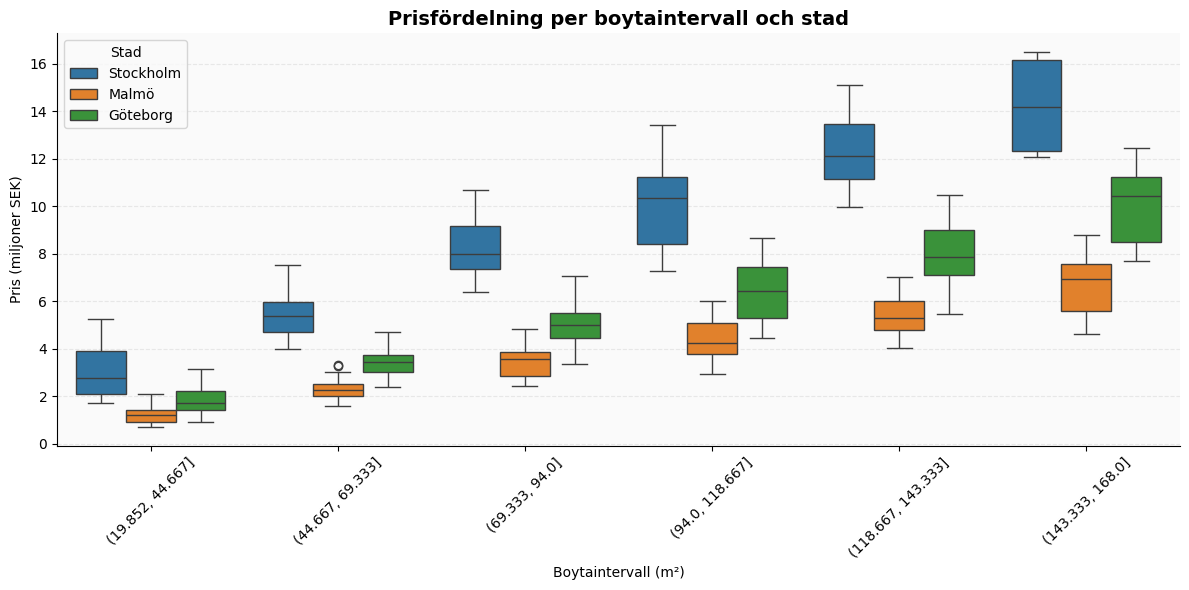

In [11]:
df_plot = df_clean.copy()
df_plot['pris_miljoner'] = df_plot['pris'] / 1_000_000

df_plot['boyta_bin'] = pd.cut(df_plot['boyta'], bins=6)

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_plot,
    x='boyta_bin',
    y='pris_miljoner',
    hue='stad'
)

plt.title("Prisfördelning per boytaintervall och stad", fontsize=14, fontweight='bold')
plt.xlabel("Boytaintervall (m²)")
plt.ylabel("Pris (miljoner SEK)")
plt.xticks(rotation=45)

plt.legend(title="Stad")

plt.tight_layout()
plt.show()

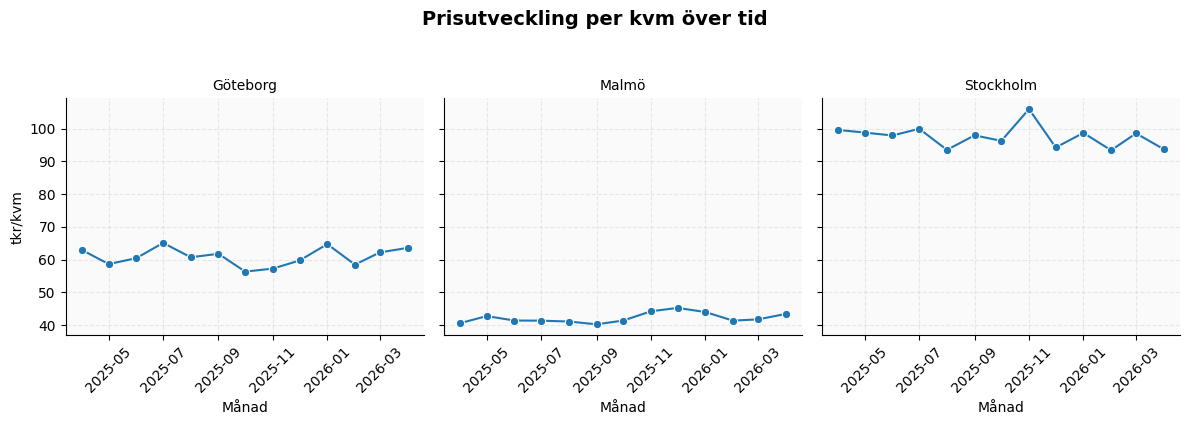

In [12]:
df_trend = df_clean.copy()
df_trend['created_at'] = pd.to_datetime(df_trend['created_at'])
df_trend['månad'] = df_trend['created_at'].dt.to_period('M')

trend = (
    df_trend
    .groupby(['månad', 'stad'])['pris_per_kvm']
    .mean()
    .reset_index()
)

trend['månad_dt'] = trend['månad'].dt.to_timestamp()
trend['pris_k'] = trend['pris_per_kvm'] / 1000

g = sns.FacetGrid(trend, col="stad", col_wrap=3, height=4, sharey=True)

g.map_dataframe(
    sns.lineplot,
    x="månad_dt",
    y="pris_k",
    marker="o"
)

g.set_axis_labels("Månad", "tkr/kvm")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.suptitle("Prisutveckling per kvm över tid", y=1.05, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()